In [1]:
# Standard Imports
import matplotlib
import scipy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
import os
import glob
import warnings
import datetime
warnings.simplefilter(action='ignore', category=FutureWarning)


In [2]:
def load_grid_info(grid_file=None, model=None):
    grid = xr.open_dataset(grid_file)
    n_lat = np.rad2deg(grid.grid_center_lat.values.reshape(tuple(np.flip(grid.grid_dims.T.values,0)))) # Reshape
    n_lon = np.rad2deg(grid.grid_center_lon.values.reshape(tuple(np.flip(grid.grid_dims.T.values,0)))) # Reshape
    grid_imask = grid.grid_imask.values.reshape(tuple(np.flip(grid.grid_dims.T.values,0))) # Reshape

    nj = xr.DataArray(np.arange(0,n_lat.shape[0],1), dims=('nj')) # Make indices
    ni = xr.DataArray(np.arange(0,n_lat.shape[1],1), dims=('ni'))
    lat = xr.DataArray(n_lat, dims=('nj','ni'), coords={'nj':nj, 'ni':ni})
    lon = xr.DataArray(n_lon, dims=('nj','ni'), coords={'nj':nj, 'ni':ni})
    imask = xr.DataArray(grid_imask, dims=('nj','ni'), coords={'nj':nj, 'ni':ni}).astype('bool') # int to bool

    if model=='NSIDC':
        lat_b = cell_bounds_to_corners(gridinfo=grid, varname='grid_corner_lat')
        lon_b = cell_bounds_to_corners(gridinfo=grid, varname='grid_corner_lon')
    else:
        raise ValueError('model not found.')

    # Combine
    return xr.Dataset({'lat':lat, 'lon':lon, 'lat_b':lat_b, 'lon_b':lon_b, 'imask':imask})

def cell_bounds_to_corners(gridinfo=None, varname=None):
    ''' Some models/obs give the four corner lat/lons for each cell. xesmf needs the bounds N+1 grid, this
    converts the former to the later.'''
    
    # Add cell bound coords (lat_b and lon_b)
    n_j = gridinfo.grid_dims.values[1]
    n_i = gridinfo.grid_dims.values[0]
    nj_b = np.arange(0, n_j + 1) # indices of corner of cells
    ni_b = np.arange(0, n_i + 1)

    # Grab all corners as arrays
    dim_out = tuple(np.flip(gridinfo.grid_dims.transpose().values,0))
    ul = gridinfo[varname].isel(grid_corners=0).values.reshape(dim_out)
    ll = gridinfo[varname].isel(grid_corners=1).values.reshape(dim_out)
    lr = gridinfo[varname].isel(grid_corners=2).values.reshape(dim_out)
    ur = gridinfo[varname].isel(grid_corners=3).values.reshape(dim_out)

    # Merge together
    m1 = np.concatenate((ul, ur[:,0][:, None]), axis=1) # add on ur at right
    m2 = np.append(ll[-1,:], lr[-1,0])
    m3 = np.concatenate((m1, m2[:, None].T), axis=0) # add ll and lr to bottom
    ds_out = xr.DataArray(m3, dims=('nj_b', 'ni_b'), coords={'nj_b':nj_b, 'ni_b':ni_b})
    ds_out = xr.ufuncs.rad2deg( ds_out ) # rad to deg
    return ds_out


In [3]:
# FYI: We regrid the matrix with xe.Regridder(grid_in, grid_out, method)
# Regridding Options
# method='conservative_normed' # ['bilinear', 'conservative', 'nearest_s2d', 'nearest_d2s', 'patch']

# When regridding from low-resolution to high-resolution, bilinear and patch will produce smooth results, 
# while conservative and nearest_s2d will preserve the original coarse grid structure (although the data 
# is now de- fined on a finer grid.).
# nearest_d2s is quite different from others: One source point can be mapped to only one destination 
# point. Because we have far less source points (on a low-resolution grid) than destination points (on a high-resolution grid), most destination points cannot receive any data so they just have zero values. 
# Only the destination points that are closest to source points can receive data.


#Demonstrate regridder on a weird ocean grid. 

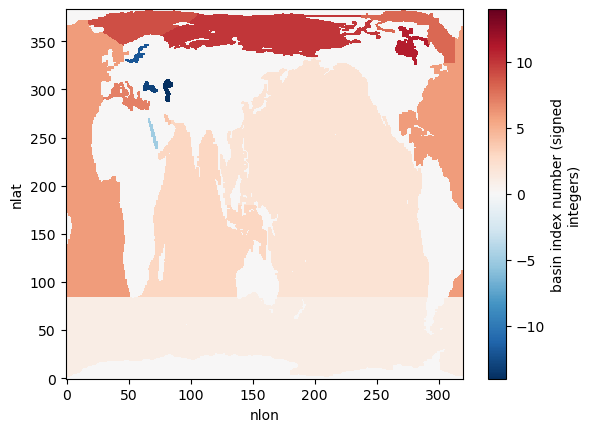

In [4]:
popregions='/glade/u/home/bitz/oldcode/shf_trends/region_masks.nc'
ds=xr.open_dataset(popregions)
#ds=ds.rename({'TLAT':'lat','TLONG':'lon'}) # not necessary 
ds.REGION_MASK.plot() # nice and weird

In [5]:
# create a traget grid that you like, or read one in from some file 
lat = xr.DataArray(np.arange(-90,92,2), dims=('lat')) 
lon = xr.DataArray(np.arange(0,360,2), dims=('lon'))
targetgrid=xr.Dataset({'lat':lat, 'lon':lon})
regridder_bilin = xe.Regridder(ds,targetgrid, method='bilinear', periodic=True)
regridder_near2 = xe.Regridder(ds,targetgrid, method='nearest_s2d', periodic=True)

In [6]:
# apply regridders
ds_bilin = regridder_bilin(ds)
ds_near2 = regridder_near2(ds)
ds_bilin # FYI

<xarray.Dataset> Size: 264kB
Dimensions:      (lat: 91, lon: 180)
Coordinates:
  * lat          (lat) int64 728B -90 -88 -86 -84 -82 -80 ... 80 82 84 86 88 90
  * lon          (lon) int64 1kB 0 2 4 6 8 10 12 ... 346 348 350 352 354 356 358
Data variables:
    REGION_MASK  (lat, lon) float64 131kB 0.0 0.0 0.0 0.0 ... 10.0 10.0 10.0
    TAREA        (lat, lon) float64 131kB 9.586e+12 9.586e+12 ... 1.291e+13
Attributes:
    regrid_method:  bilinear

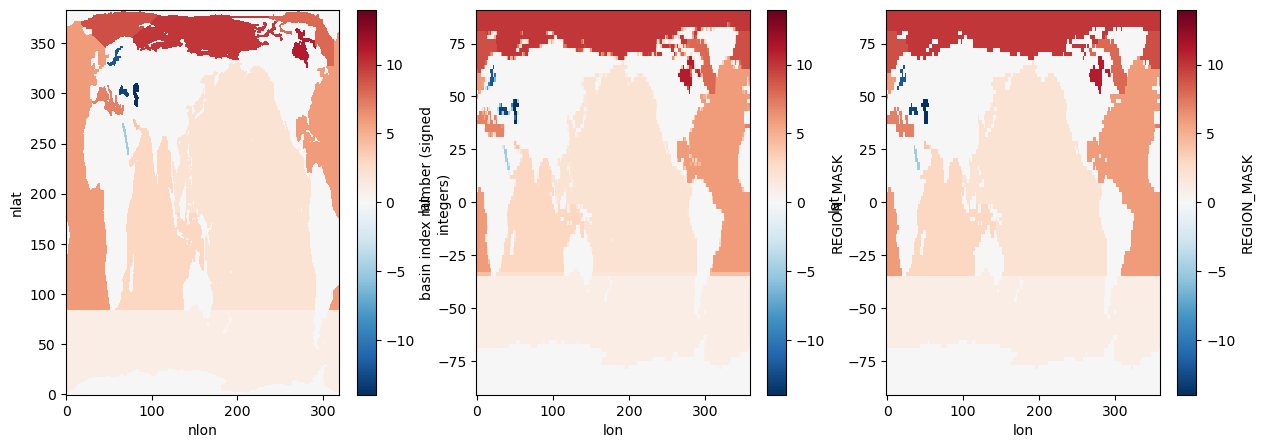

In [7]:
f, ax = plt.subplots(nrows=1,ncols=3)
f.set_size_inches(15,5)
ax = ax.reshape(-1)

ds.REGION_MASK.plot(ax=ax[0])
ds_bilin.REGION_MASK.plot(ax=ax[1])
ds_near2.REGION_MASK.plot(ax=ax[2])

## demonstrate the regridder by regridding the areacello file for all the files I had lieing around

In [8]:
def homogenize_coords(ds):

    coords = [a for a in ds.coords]

    if 'latitude' in coords:
        ds=ds.rename({'latitude':'lat'})
    elif 'nav_lat' in coords:
        ds=ds.rename({'nav_lat':'lat'})
    elif 'lat' not in coords:
        print('Unknown Var for Latitude, good luck ',coords)

    if 'longitude' in coords:
        ds=ds.rename({'longitude':'lon'})
    elif 'nav_lon' in coords:
        ds=ds.rename({'nav_lon':'lon'})
    elif 'lon' not in coords:
        print('Unknown Var for Longitude, good luck ',coords)
    
    if 'lat_bnds' in coords:
        ds=ds.rename({'lat_bnds':'lat_b'})
    elif 'vertices_latitude' in coords:
        ds=ds.rename({'vertices_latitude':'lat_b'})
    elif 'bounds_nav_lat' in coords:
        ds=ds.rename({'bounds_nav_lat':'lat_b'})
        
    if 'lon_bnds' in coords:
        ds=ds.rename({'lon_bnds':'lon_b'})
    elif 'vertices_longitude' in coords:
        ds=ds.rename({'vertices_longitude':'lon_b'})
    elif 'bounds_nav_lon' in coords:
        ds=ds.rename({'bounds_nav_lon':'lon_b'})
        
    return ds

In [15]:
models = [ 'GFDL-ESM4', 'MIROC-ES2L', 'MIROC6','CanESM5','CNRM-CM6-1',
          'CNRM-ESM2-1','EC-Earth3','EC-Earth3-Veg','IPSL-CM6A-LR','GFDL-CM4',
          'NorESM2-LM','SAM0-UNICON','UKESM1-0-LL','CAMS-CSM1-0','MRI-ESM2-0',
          'CESM2','BCC-ESM1','MPI-ESM1-2-LR','MPI-ESM1-2-HR','FGOALS-f3-L','FGOALS-g3',
          'NESM3','GISS-E2-1-G','FIO-ESM-2-0']

method = 'nearest_s2d'       #method = 'nearest_d2s'  # this was bad do not use

fieldregridded=[]  # this is my GF except haven't yet divided by patch heat flux forcing, which is 12 W m-2

for model in models:
    if model=='NESM3':
        model_area_file =  glob.glob('areacello_Ofx_CESM2_*.nc') # oddly NESM3's areacello is bad, so use the one from CESM2
    elif model=='GISS-E2-1-G':
        model_area_file =  glob.glob('areacella_fx_GISS-E2-1-G_*.nc') # sea ice is on atm grid, need to change for ocean!
    else:
        model_area_file =  glob.glob('areacello_Ofx_'+model+'_*.nc')
        
    model_area_file = model_area_file[0]
    ds_model = xr.open_dataset(model_area_file)
    if model=='BCC-ESM1':
        ds_model=ds_model.rename({'lat':'x','lon':'y'}) # not sure this is necessary

    ds_model = homogenize_coords(ds_model)  # try to fix all the weirdo coords
    if model=='GISS-E2-1-G':
        ds_model=ds_model.rename({'areacella':'areacello'}) # just change the name for convenience
    elif model == 'NorESM2-LM':  # for some odd reason the latitude repeats at j=384 and 385
        ds_model=ds_model.isel(j=slice(0,384))  # so ditch it
    elif model in ['FGOALS-f3-L','FGOALS-g3']: # reversed relative to their output data, grr
        #print(ds_model)
        tmp=ds_model.areacello
        tmp=tmp.transpose('j','i')
        Axr=xr.DataArray(tmp.values[::-1,:], dims=('j','i'))
        Axr.coords['lat']=xr.DataArray(tmp.lat.values[::-1,:], dims=('j','i'))
        Axr.coords['lon']=xr.DataArray(tmp.lon.values[::-1,:], dims=('j','i'))
        Axr.coords['j']=tmp.j
        Axr.coords['i']=tmp.i
        ds_model=Axr.to_dataset(name='areacello')
        ds_model['areacello']=ds_model['areacello'].where(ds_model['areacello']<1e12, other = np.nan)
        ds_keep=ds_model
        #print(ds_model)
        
    # regrid from model to traget
    regridder = xe.Regridder(ds_model, targetgrid, method, periodic=True)
    model_regridded = regridder(ds_model)

    field = model_regridded['areacello']
    field = field.assign_coords(model=model)
    field = field.expand_dims('model')
    field.name='areacello'
    field = field.where(~isnan(field), other = 0.)
    
    fieldregridded.append(field)


fieldregridded=xr.concat(fieldregridded,'model')

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NameError: name 'isnan' is not defined

## This plot shows us how the regional area mask of the models compares to the NSIDC regional area mask. Oddly the Central Arctic tends to be low in the models, not sure why.

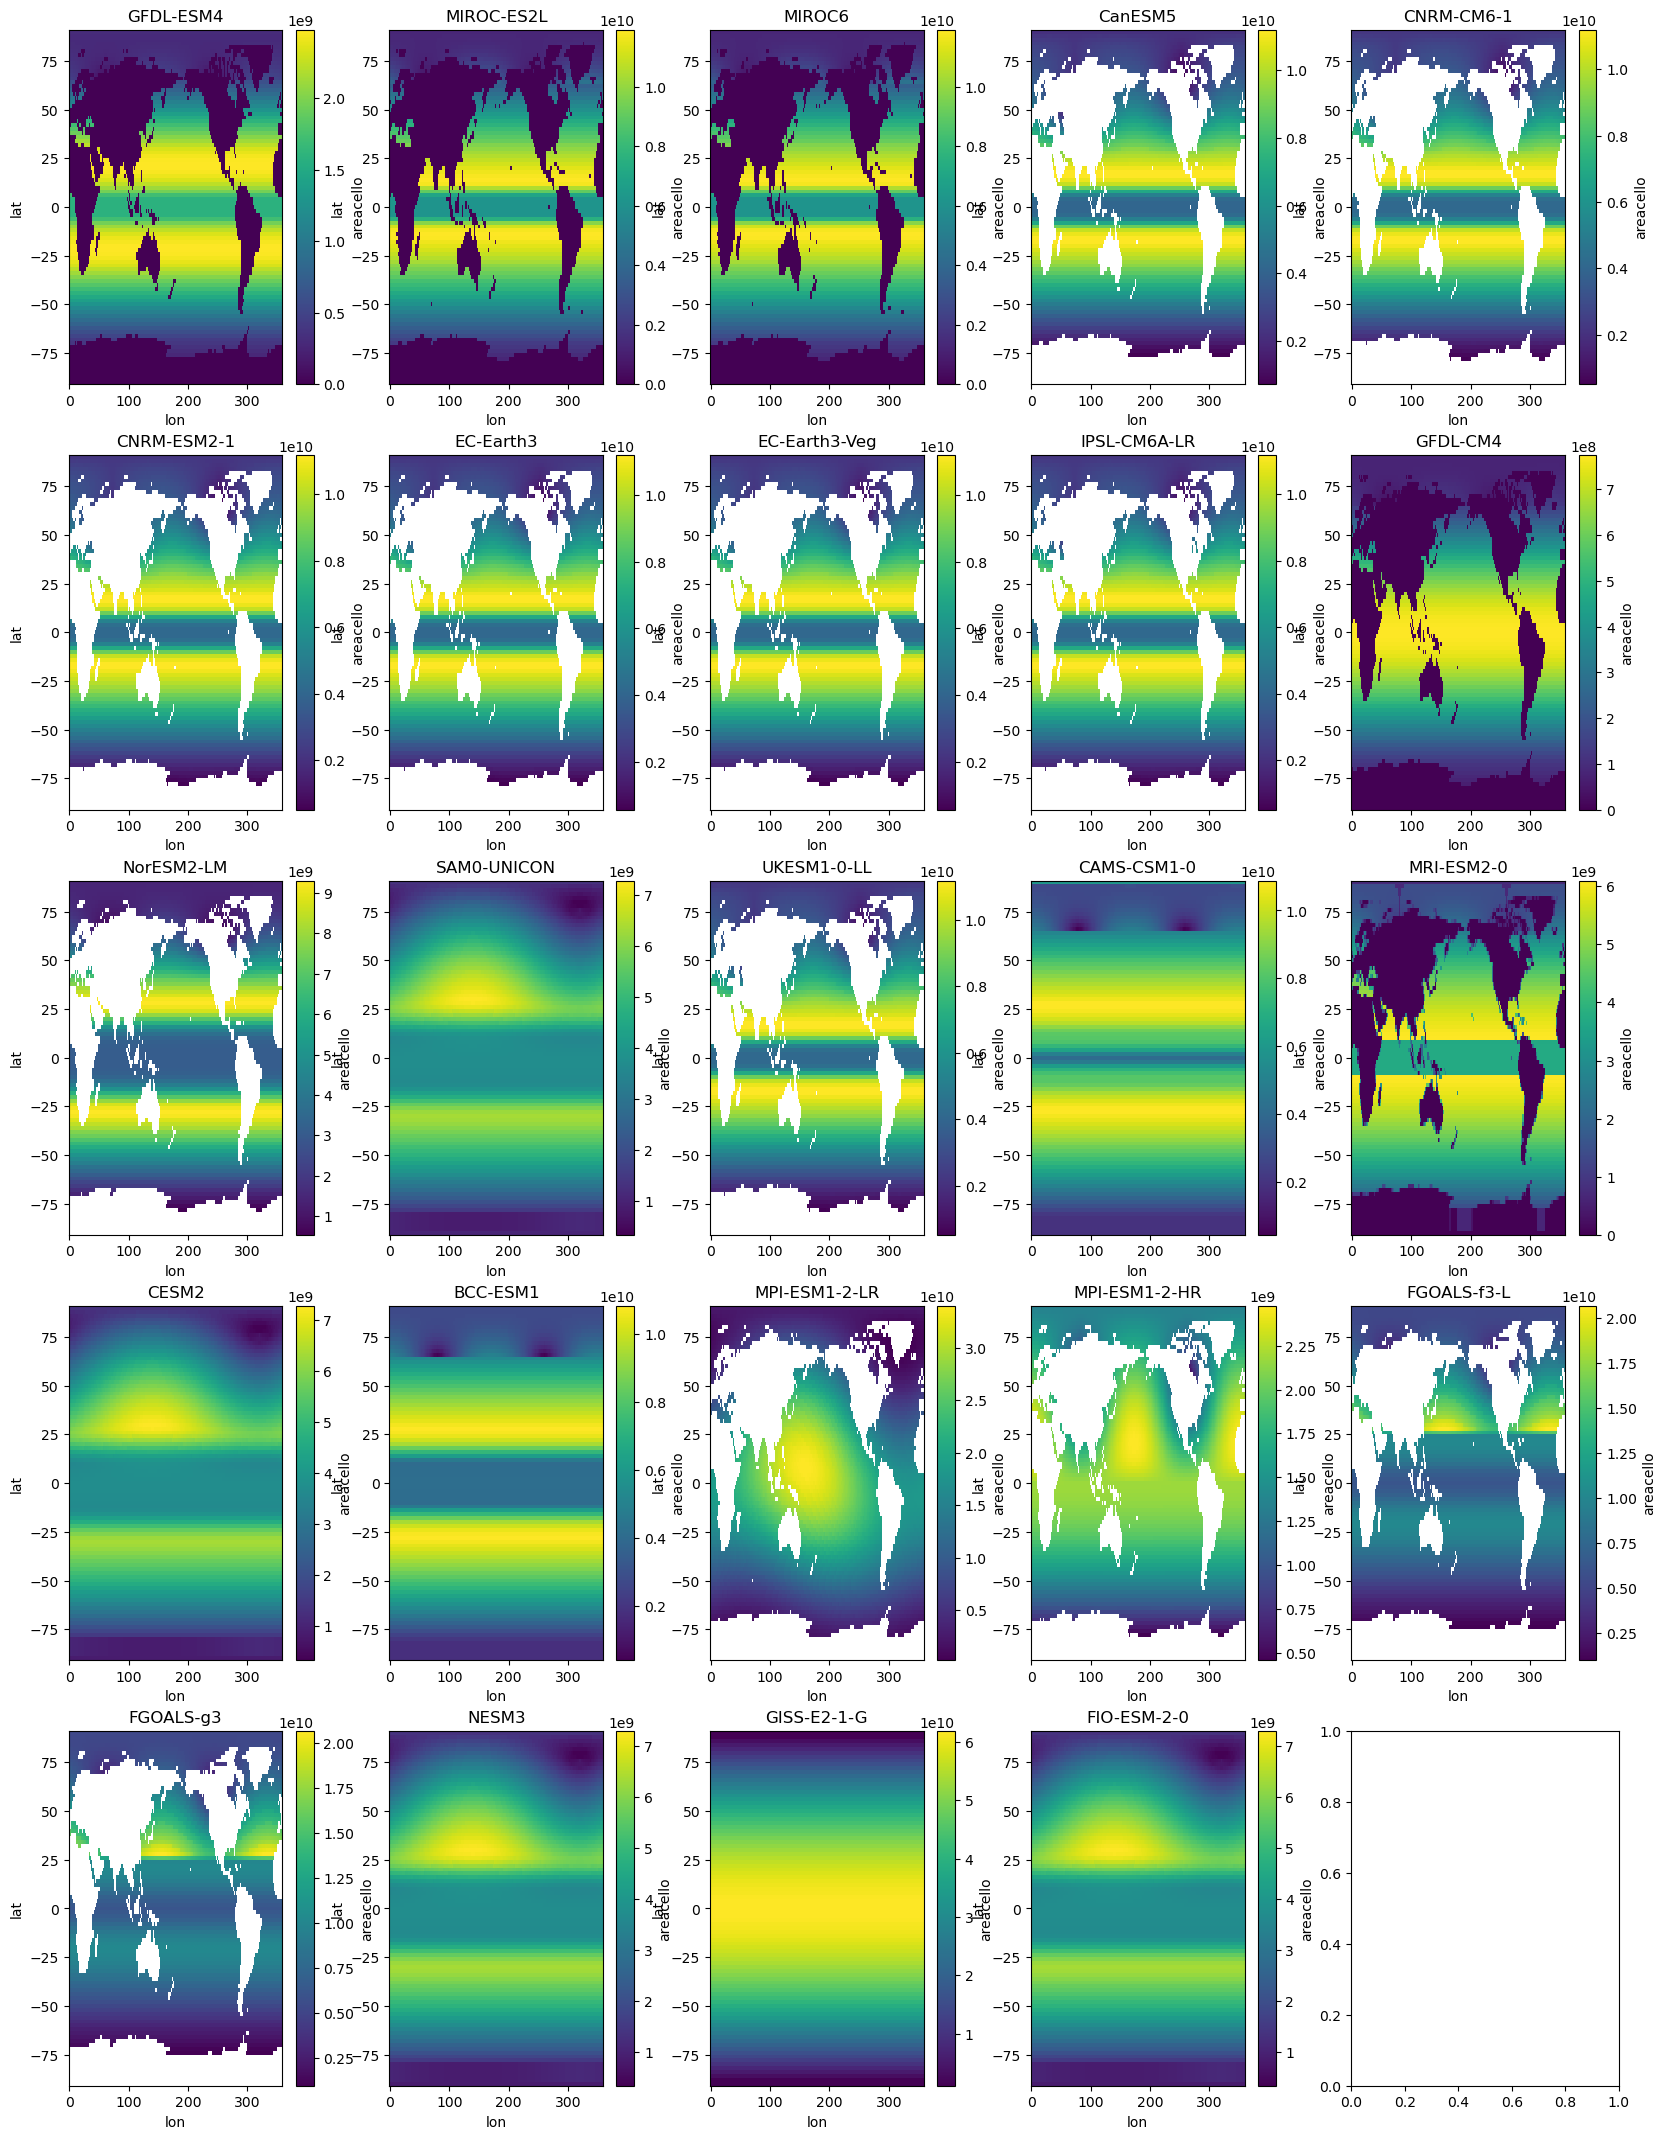

In [12]:
f, ax = plt.subplots(nrows=5,ncols=5)
f.set_size_inches(20,26.7)
ax = ax.reshape(-1)
for (im,model) in enumerate(models):
    ds_model = fieldregridded.sel(model=model)
    ds_model.plot.pcolormesh( ax=ax[im], label=model )
    ax[im].set_title(model)
    
f.savefig('AllModelsAreacello.png',bbox_inches='tight',dpi=200)

In [11]:
# FGOALS looks odd but the rest seem okay